# SqueezeNet Platform Comparison & Result Export

This notebook runs the comprehensive SqueezeNet benchmark (using the existing `SqueezeNetBenchmarker` class) and saves results in **both JSON and CSV** formats matching the structure in previously generated files:

- `squeezenet_results_<timestamp>.json`
- `squeezenet_summary_<timestamp>.csv`

You can adjust the number of runs or enable quantization below. The format is intentionally kept identical to the standalone script for consistency across automated + interactive workflows.

In [35]:
# Imports & utilities
import os, json, platform, psutil, sys, time
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from tqdm import tqdm

# Reuse (light) version of SqueezeNetBenchmarker if script not imported
try:
    from squeezenet_benchmark import SqueezeNetBenchmarker
except ImportError:
    class SqueezeNetBenchmarker:
        def __init__(self, use_quantized=False):
            self.model=None; self.device=None; self.test_input=None; self.model_size_mb=0; self.use_quantized=use_quantized
        def setup(self):
            if torch.backends.mps.is_available(): self.device=torch.device('mps')
            elif torch.cuda.is_available(): self.device=torch.device('cuda')
            else: self.device=torch.device('cpu')
            self.model = models.squeezenet1_1(pretrained=True).eval().to(self.device)
            if self.use_quantized:
                self.model = torch.quantization.quantize_dynamic(self.model,{torch.nn.Linear, torch.nn.Conv2d},dtype=torch.qint8)
            self.model_size_mb = sum(p.nelement()*p.element_size() for p in self.model.parameters())/(1024*1024)
            self.test_input = torch.randn(1,3,224,224).to(self.device)
        def benchmark_core_performance(self, num_runs=50, warmup_runs=10):
            for _ in range(warmup_runs):
                with torch.no_grad(): _ = self.model(self.test_input)
            if self.device.type in ['cuda','mps'] and self.device.type=='cuda': torch.cuda.synchronize()
            times=[]; cpu=[]; mem=[]; gpu=[]; proc=psutil.Process()
            for _ in tqdm(range(num_runs), desc='Benchmarking'):
                start=time.perf_counter();
                with torch.no_grad(): _=self.model(self.test_input)
                if self.device.type=='cuda': torch.cuda.synchronize()
                end=time.perf_counter()
                times.append((end-start)*1000)
                cpu.append(proc.cpu_percent())
                mem.append(proc.memory_info().rss/(1024*1024))
                gpu.append(torch.cuda.memory_allocated()/(1024*1024) if self.device.type=='cuda' else 0)
            import numpy as np
            return {'inference_times':times,'cpu_usage':cpu,'memory_usage':mem,'gpu_memory_usage':gpu,'statistics':{
                'mean_inference_time':float(np.mean(times)), 'std_inference_time':float(np.std(times)),
                'min_inference_time':float(np.min(times)),'max_inference_time':float(np.max(times)),
                'p95_inference_time':float(np.percentile(times,95)),'p99_inference_time':float(np.percentile(times,99)),
                'mean_memory_usage':float(np.mean(mem)),'peak_memory_usage':float(np.max(mem)),
                'mean_cpu_usage':float(np.mean(cpu)),'peak_cpu_usage':float(np.max(cpu)),
                'mean_gpu_memory':float(np.mean(gpu)),'peak_gpu_memory':float(np.max(gpu))}}
        def benchmark_latency_scenarios(self, network_delays=[0,50,500]):
            results={}
            for d in network_delays:
                inf=[]; tot=[]; over=[]
                for _ in range(10):
                    t0=time.perf_counter(); time.sleep(d/1000.0)
                    s=time.perf_counter();
                    with torch.no_grad(): _=self.model(self.test_input)
                    if self.device.type=='cuda': torch.cuda.synchronize()
                    e=time.perf_counter(); time.sleep(d/1000.0); t1=time.perf_counter()
                    inf.append((e-s)*1000); tot.append((t1-t0)*1000); over.append((t1-t0 - (e-s))*1000)
                inf=np.array(inf); tot=np.array(tot); over=np.array(over)
                results[d]={'mean_inference':float(np.mean(inf)),'mean_total':float(np.mean(tot)),'mean_network_overhead':float(np.mean(over)),'efficiency_ratio':float(np.mean(inf)/np.mean(tot)*100)}
            return results
        def benchmark_batch_processing(self, batch_sizes=[1,5,10]):
            out={}
            for bs in batch_sizes:
                times=[]; mems=[]; proc=psutil.Process(); batch=torch.randn(bs,3,224,224).to(self.device)
                for _ in range(5):
                    st=time.perf_counter(); m0=proc.memory_info().rss/(1024*1024)
                    with torch.no_grad(): _=self.model(batch)
                    if self.device.type=='cuda': torch.cuda.synchronize()
                    en=time.perf_counter(); m1=proc.memory_info().rss/(1024*1024)
                    times.append((en-st)*1000); mems.append(m1)
                import numpy as np
                avg=float(np.mean(times)); out[bs]={'total_time':avg,'time_per_image':avg/bs,'throughput':bs/(avg/1000),'memory_usage':float(np.mean(mems))}
            return out
        def benchmark_cold_warm_start(self, num_trials=5):
            cold=[]; warm=[]
            for _ in range(num_trials):
                mdl=models.squeezenet1_1(pretrained=True).eval().to(self.device)
                st=time.perf_counter();
                with torch.no_grad(): _=mdl(self.test_input)
                if self.device.type=='cuda': torch.cuda.synchronize();
                cold.append((time.perf_counter()-st)*1000)
                st=time.perf_counter();
                with torch.no_grad(): _=mdl(self.test_input)
                if self.device.type=='cuda': torch.cuda.synchronize();
                warm.append((time.perf_counter()-st)*1000)
            import numpy as np
            return {'cold_starts':cold,'warm_starts':warm,'statistics':{
                'cold_start_mean':float(np.mean(cold)),'cold_start_std':float(np.std(cold)),
                'warm_start_mean':float(np.mean(warm)),'warm_start_std':float(np.std(warm)),
                'startup_overhead':float(np.mean(cold)-np.mean(warm))}}
        def run_comprehensive_benchmark(self, num_runs=50):
            res={'timestamp':datetime.now().isoformat(),'device_info':{'system':platform.system(),'release':platform.release(),'machine':platform.machine(),'processor':platform.processor(),'cpu_cores':psutil.cpu_count(),'total_ram_gb':psutil.virtual_memory().total/(1024**3),'python_version':sys.version,'pytorch_version':torch.__version__,'device_type':str(self.device)},'model_info':{'name':'SqueezeNet','type':'Lightweight CNN','size_mb':self.model_size_mb,'input_shape':[1,3,224,224],'output_shape':[1,1000],'quantized':self.use_quantized,'device':str(self.device)}}
            res['core_performance']=self.benchmark_core_performance(num_runs)
            res['latency_analysis']=self.benchmark_latency_scenarios()
            res['batch_processing']=self.benchmark_batch_processing()
            res['cold_warm_analysis']=self.benchmark_cold_warm_start()
            return res
        def save_results(self, results, output_dir='results'):
            p=Path(output_dir); p.mkdir(exist_ok=True)
            ts=datetime.now().strftime('%Y%m%d_%H%M%S')
            json_file=p/f'squeezenet_results_{ts}.json'
            with open(json_file,'w') as f: json.dump(results,f,indent=2)
            core=results['core_performance']['statistics']; cw=results['cold_warm_analysis']['statistics']
            summary={ 'Model':['SqueezeNet'], 'Device_Tier':['Laptop (Tier 2)'], 'Device_Type':[results['model_info']['device']], 'Model_Size_MB':[results['model_info']['size_mb']], 'Quantized':[results['model_info']['quantized']], 'Mean_Inference_Time_ms':[core['mean_inference_time']], 'Std_Inference_Time_ms':[core['std_inference_time']], 'P95_Inference_Time_ms':[core['p95_inference_time']], 'Mean_Memory_Usage_MB':[core['mean_memory_usage']], 'Peak_Memory_Usage_MB':[core['peak_memory_usage']], 'Mean_CPU_Usage_Percent':[core['mean_cpu_usage']], 'GPU_Memory_MB':[core.get('peak_gpu_memory',0)], 'Cold_Start_Overhead_ms':[cw['startup_overhead']], 'Max_Throughput_imgs_per_sec':[max([results['batch_processing'][bs]['throughput'] for bs in results['batch_processing']])], 'Efficiency_No_Network_Percent':[results['latency_analysis'][0]['efficiency_ratio']], 'Efficiency_500ms_Network_Percent':[results['latency_analysis'][500]['efficiency_ratio']] }
            df=pd.DataFrame(summary); csv_file=p/f'squeezenet_summary_{ts}.csv'; df.to_csv(csv_file,index=False)
            return json_file, csv_file

## Evaluation Metric Visualizations
The following cells load multi-platform SqueezeNet benchmark JSON outputs and generate the recommended plots:
1. Latency comparison (mean inference time)
2. Resource usage (CPU / Memory) and model size indicator
3. Network efficiency vs simulated delay
4. Cold vs warm start times
5. Quantization status summary

In [36]:
# Load multi-platform JSON results (improved path discovery)
import json, glob, os
from pathlib import Path

# Determine project root (two levels up from this notebook file location)
notebook_dir = Path.cwd()
# Try to locate the central 'results' directory
possible_results = [
    notebook_dir / 'results',                 # same dir as notebook (unlikely)
    notebook_dir.parent / 'results',          # parent of inference_evaluation
    notebook_dir.parent.parent / 'results'    # project root
]
results_root = None
for cand in possible_results:
    if cand.exists() and (cand / 'pc').exists():
        results_root = cand
        break
if results_root is None:
    # fallback: search upward for a directory containing expected subfolders
    for up in notebook_dir.parents:
        if (up / 'results').exists():
            results_root = up / 'results'
            break

if results_root is None:
    raise FileNotFoundError('Could not locate results directory. Checked: ' + ', '.join(str(p) for p in possible_results))

print(f'Using results root: {results_root}')

PLATFORM_SUBDIRS = {
    'PC': 'pc',
    'Raspberry Pi': 'rpi',
    'NVIDIA GPU': 'nvidia_gpu'
}

JSON_PATTERNS = [
    'squeezenet_results_*.json',  # naming from benchmark script
    'squeezenet*.json',           # generic fallback
    '*squuezenet*.json'           # typo variant present in repo
]

platform_results = {}
for platform_name, subdir in PLATFORM_SUBDIRS.items():
    platform_dir = results_root / subdir
    if not platform_dir.exists():
        print(f'Skip {platform_name} (missing dir: {platform_dir})')
        continue
    matched_files = []
    for pattern in JSON_PATTERNS:
        matched_files.extend(sorted(platform_dir.glob(pattern)))
    # Deduplicate preserving order
    seen=set(); unique_files=[]
    for f in matched_files:
        if f not in seen:
            unique_files.append(f); seen.add(f)
    if not unique_files:
        print(f'Skip {platform_name} (no JSON matches)')
        continue
    latest = unique_files[-1]
    try:
        with open(latest) as f:
            data = json.load(f)
        # Basic schema check
        if 'core_performance' not in data or 'statistics' not in data['core_performance']:
            print(f'Warning: {latest.name} missing expected statistics section; skipping')
            continue
        platform_results[platform_name] = data
        print(f'Loaded {platform_name}: {latest.name}')
    except Exception as e:
        print(f'Error loading {latest}: {e}')

print('Platforms loaded:', list(platform_results.keys()))
len(platform_results)

Using results root: /Users/belix/Documents/edgeai-env/results
Loaded PC: squeezenet_results_20250623_135253.json
Loaded Raspberry Pi: squuezenet.json
Loaded NVIDIA GPU: squeezenet_nvidia_results_20250923_121845.json
Platforms loaded: ['PC', 'Raspberry Pi', 'NVIDIA GPU']


3

Raw latency rows: [{'Platform': 'PC', 'Mean_ms': 26.50707136, 'P95_ms': 34.55716200000034}, {'Platform': 'Raspberry Pi', 'Mean_ms': 39.14199338010803, 'P95_ms': 39.80631220256328}, {'Platform': 'NVIDIA GPU', 'Mean_ms': 1.771662081591785, 'P95_ms': 1.8277620896697044}]


/var/folders/h5/hc2xh1kd70zcs1snh4247v2w0000gn/T/ipykernel_50607/1944322384.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=lat_df,x='Mean_ms',y='Platform',palette='viridis')


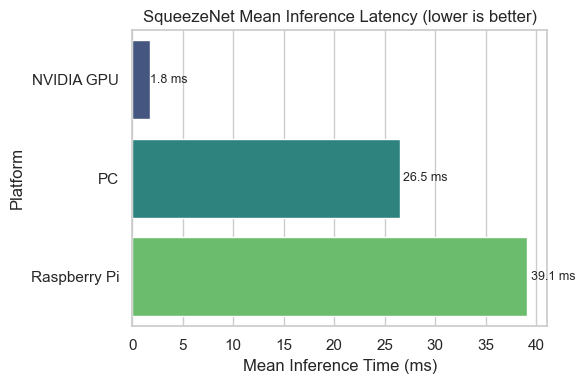

,Platform,Mean_ms,P95_ms
2,NVIDIA GPU,1.771662,1.827762
0,PC,26.507071,34.557162
1,Raspberry Pi,39.141993,39.806312


In [37]:
# 1. Latency comparison bar chart
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')

lat_rows=[]
for plat,data in list(platform_results.items()):
    try:
        stats=data['core_performance']['statistics']
        mean_val=stats.get('mean_inference_time')
        p95_val=stats.get('p95_inference_time')
        if mean_val is None:
            print(f"Warning: missing mean_inference_time for {plat}")
            continue
        lat_rows.append({'Platform':plat,'Mean_ms':mean_val,'P95_ms':p95_val})
    except KeyError as e:
        print(f"Skipping {plat}, missing key: {e}")

lat_df=pd.DataFrame(lat_rows)
print('Raw latency rows:', lat_rows)
if lat_df.empty:
    print('No latency data available. Check that JSON files loaded contain core_performance.statistics.')
else:
    if 'Mean_ms' not in lat_df.columns:
        print('Mean_ms column missing after DataFrame creation; columns are:', lat_df.columns.tolist())
    else:
        lat_df=lat_df.sort_values('Mean_ms')
        plt.figure(figsize=(6,4))
        ax=sns.barplot(data=lat_df,x='Mean_ms',y='Platform',palette='viridis')
        
        # Fix text positioning to match the sorted order
        for bar_idx, (df_idx, row) in enumerate(lat_df.iterrows()):
            ax.text(row['Mean_ms']*1.01, bar_idx, f"{row['Mean_ms']:.1f} ms", va='center', fontsize=9)
        
        plt.title('SqueezeNet Mean Inference Latency (lower is better)')
        plt.xlabel('Mean Inference Time (ms)')
        plt.ylabel('Platform')
        plt.tight_layout()
        plt.show()
lat_df

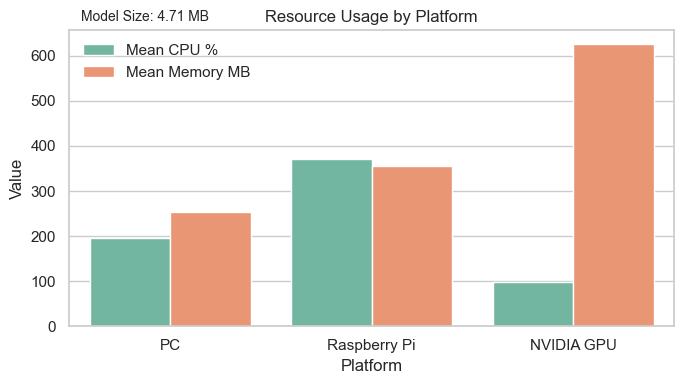

,Platform,Metric,Value
0,PC,Mean CPU %,195.330000
1,PC,Mean Memory MB,254.551094
2,Raspberry Pi,Mean CPU %,371.502000
3,Raspberry Pi,Mean Memory MB,355.350469
4,NVIDIA GPU,Mean CPU %,97.655000
5,NVIDIA GPU,Mean Memory MB,625.125000


In [38]:
# 2. Resource usage grouped bars (CPU, Memory) + model size annotation
res_rows=[]
for plat,data in platform_results.items():
    stats=data['core_performance']['statistics']
    res_rows.append({'Platform':plat,'Metric':'Mean CPU %','Value':stats['mean_cpu_usage']})
    res_rows.append({'Platform':plat,'Metric':'Mean Memory MB','Value':stats['mean_memory_usage']})
res_df=pd.DataFrame(res_rows)

plt.figure(figsize=(7,4))
ax=sns.barplot(data=res_df,x='Platform',y='Value',hue='Metric',palette='Set2')
plt.title('Resource Usage by Platform')
plt.ylabel('Value')
plt.xlabel('Platform')
plt.legend(frameon=False)
# Model size: assume same so show once; else could loop
model_size=next(iter(platform_results.values()))['model_info']['size_mb'] if platform_results else 0
plt.text(0.02,1.02,f"Model Size: {model_size:.2f} MB",transform=ax.transAxes,fontsize=10,ha='left',va='bottom')
plt.tight_layout(); plt.show()
res_df

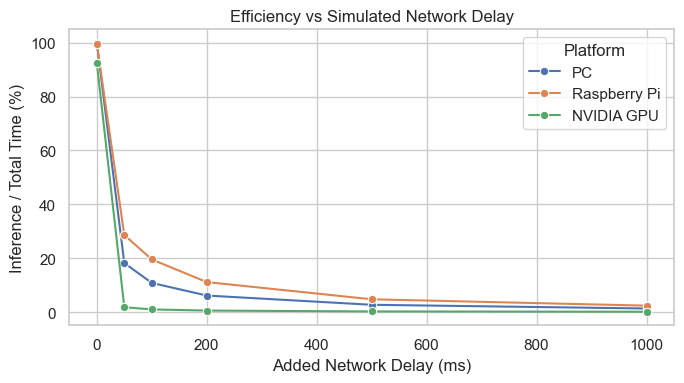

,Platform,Delay_ms,Efficiency_%
0,PC,0,99.968093
1,PC,50,18.200624
2,PC,100,10.813756
3,PC,200,6.129472
4,PC,500,2.697160


In [39]:
# 3. Network efficiency vs simulated delay (if latency_analysis present)
net_rows=[]
for plat,data in platform_results.items():
    lat_analysis=data.get('latency_analysis', {})
    for delay,vals in lat_analysis.items():
        net_rows.append({'Platform':plat,'Delay_ms':int(delay),'Efficiency_%':vals['efficiency_ratio']})
net_df=pd.DataFrame(net_rows)
if not net_df.empty:
    plt.figure(figsize=(7,4))
    sns.lineplot(data=net_df,x='Delay_ms',y='Efficiency_%',hue='Platform',marker='o')
    plt.title('Efficiency vs Simulated Network Delay')
    plt.ylabel('Inference / Total Time (%)')
    plt.xlabel('Added Network Delay (ms)')
    plt.tight_layout(); plt.show()
net_df.head()

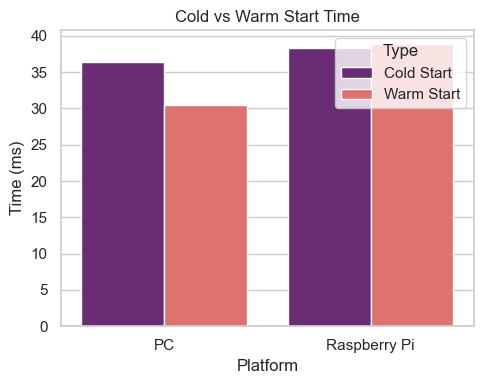

,Platform,Quantized,Status
0,PC,False,FP32
1,Raspberry Pi,False,FP32
2,NVIDIA GPU,False,FP32


In [40]:
# 4. Cold vs Warm start bar chart & 5. Quantization status
cold_rows=[]; quant_rows=[]
for plat,data in platform_results.items():
    cw=data.get('cold_warm_analysis',{}).get('statistics',{})
    if cw:
        cold_rows.append({'Platform':plat,'Type':'Cold Start','Time_ms':cw['cold_start_mean']})
        cold_rows.append({'Platform':plat,'Type':'Warm Start','Time_ms':cw['warm_start_mean']})
    quant_rows.append({'Platform':plat,'Quantized':data['model_info'].get('quantized',False)})

cold_df=pd.DataFrame(cold_rows); quant_df=pd.DataFrame(quant_rows)
if not cold_df.empty:
    plt.figure(figsize=(5,4))
    sns.barplot(data=cold_df,x='Platform',y='Time_ms',hue='Type',palette='magma')
    plt.title('Cold vs Warm Start Time')
    plt.ylabel('Time (ms)'); plt.xlabel('Platform')
    plt.tight_layout(); plt.show()

# Quantization summary display
quant_df['Status']=quant_df['Quantized'].map({True:'INT8 / Quantized', False:'FP32'})
quant_df

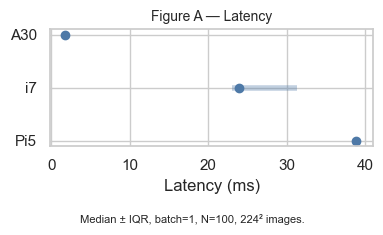

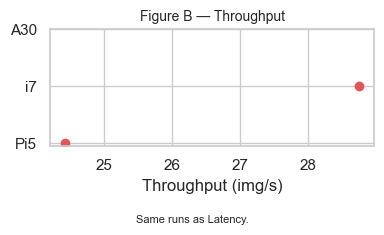

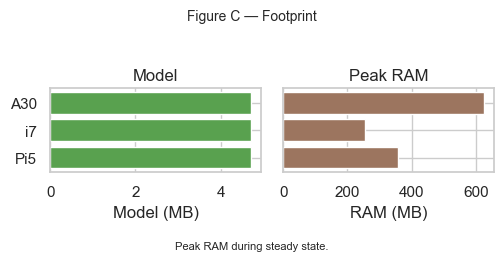

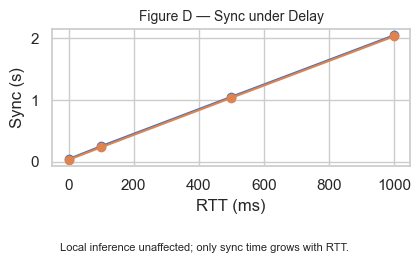

,Platform,Tag,Median_ms,IQR_ms,Throughput_img_s,Model_MB,Peak_RAM_MB
1,Raspberry Pi,Pi5,38.810670,0.498681,24.426217,4.713043,358.859375
0,PC,i7,23.976251,8.349324,28.759553,4.713043,254.570312
2,NVIDIA GPU,A30,1.762779,0.031022,NaN,4.713043,625.125000


In [41]:
# Compact Results Figures A-D with Short Labels
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')

# --- Helper: short platform tags ---
def short_tag(name:str)->str:
    if not isinstance(name,str):
        return str(name)
    n=name.lower()
    if 'pi' in n: return 'Pi5'
    if 'laptop' in n or 'i7' in n or 'pc' in n: return 'i7'
    if 'nvidia' in n or 'gpu' in n: return 'A30'
    return name[:10]

# Gather per-platform metrics
records=[]
for plat,data in platform_results.items():
    stats=data['core_performance']['statistics']
    inf_times=data['core_performance'].get('inference_times', [])
    batch_info=data.get('batch_processing', {})
    batch1 = None
    if isinstance(batch_info, dict):
        # find batch size 1 (could be key '1' or 1)
        for k,v in batch_info.items():
            if str(k)=='1':
                batch1=v; break
    throughput = batch1.get('throughput') if batch1 else None
    peak_mem = stats.get('peak_memory_usage')
    model_mb = data['model_info'].get('size_mb', np.nan)
    if inf_times:
        arr=np.array(inf_times)
        median=np.median(arr)
        q1=np.percentile(arr,25)
        q3=np.percentile(arr,75)
        iqr=q3-q1
        n=len(arr)
    else:
        median=q1=q3=iqr=np.nan; n=0
    records.append({
        'Platform':plat,
        'Tag':short_tag(plat),
        'Median_ms':median,
        'Q1_ms':q1,
        'Q3_ms':q3,
        'IQR_ms':iqr,
        'N':n,
        'Throughput_img_s':throughput,
        'Model_MB':model_mb,
        'Peak_RAM_MB':peak_mem
    })

plot_df=pd.DataFrame(records)
if plot_df.empty:
    print('No data to plot for compact figures.')
else:
    # Ensure consistent order Pi5, i7, A30 (removed Colab)
    order=[t for t in ['Pi5','i7','A30'] if t in plot_df['Tag'].values]
    plot_df['Tag']=pd.Categorical(plot_df['Tag'], categories=order, ordered=True)
    plot_df=plot_df.sort_values('Tag')
    # Figure A: Latency (Horizontal dot plot Median ± IQR)
    figA, axA = plt.subplots(figsize=(4.0,2.2))
    for i,(idx,row) in enumerate(plot_df.iterrows()):
        if not np.isnan(row['Median_ms']):
            axA.hlines(y=i, xmin=row['Q1_ms'], xmax=row['Q3_ms'], color='#4E79A7', lw=4, alpha=0.35)
            axA.plot(row['Median_ms'], i, 'o', color='#4E79A7')
    axA.set_yticks(range(len(plot_df)))
    axA.set_yticklabels(plot_df['Tag'])
    axA.set_xlabel('Latency (ms)')
    axA.set_ylabel('')
    axA.set_title('Figure A — Latency', fontsize=10)
    # Caption
    n_vals=plot_df['N'].unique()
    if len(n_vals)==1:
        n_caption=f"N={int(n_vals[0])}"
    else:
        n_caption=f"N={','.join(map(str,n_vals))}"
    figA.text(0.5,-0.05,f"Median ± IQR, batch=1, {n_caption}, 224² images.",ha='center',fontsize=8)
    figA.tight_layout()
    plt.show()

    # Figure B: Throughput (Horizontal dot plot)
    figB, axB = plt.subplots(figsize=(4.0,2.2))
    for i,(idx,row) in enumerate(plot_df.iterrows()):
        tp=row['Throughput_img_s']
        if tp and not np.isnan(tp):
            axB.plot(tp, i, 'o', color='#E15759')
    axB.set_yticks(range(len(plot_df)))
    axB.set_yticklabels(plot_df['Tag'])
    axB.set_xlabel('Throughput (img/s)')
    axB.set_ylabel('')
    axB.set_title('Figure B — Throughput', fontsize=10)
    figB.text(0.5,-0.05,"Same runs as Latency.",ha='center',fontsize=8)
    figB.tight_layout()
    plt.show()

    # Figure C: Footprint (Model vs Peak RAM) small multiples
    figC, (axC1, axC2) = plt.subplots(1,2, figsize=(5.2,2.2), sharey=True)
    axC1.barh(plot_df['Tag'], plot_df['Model_MB'], color='#59A14F')
    axC1.set_xlabel('Model (MB)')
    axC1.set_ylabel('')
    axC1.set_title('Model')
    axC2.barh(plot_df['Tag'], plot_df['Peak_RAM_MB'], color='#9C755F')
    axC2.set_xlabel('RAM (MB)')
    axC2.set_title('Peak RAM')
    figC.suptitle('Figure C — Footprint', fontsize=10, y=1.04)
    figC.text(0.5,-0.05,'Peak RAM during steady state.',ha='center',fontsize=8)
    figC.tight_layout()
    plt.show()

    # Figure D: Sync under delay (line chart). Use mean_total from latency_analysis => sync time (s)
    # Collect delays present across platforms
    sync_rows=[]
    desired_bins=[0,100,250,500,1000]
    for plat,data in platform_results.items():
        la=data.get('latency_analysis', {})
        # Map keys to ints
        entries=[]
        for k,v in la.items():
            try:
                d=int(k)
                mt=v.get('mean_total')
                if mt is not None:
                    entries.append((d, mt/1000.0)) # convert ms to s
            except Exception:
                continue
        if not entries:
            continue
        # If desired bins not fully present, just use available sorted
        entries=sorted(entries, key=lambda x:x[0])
        for d,val in entries:
            if d in desired_bins or len(desired_bins)==0:
                sync_rows.append({'Tag':short_tag(plat),'RTT_ms':d,'Sync_s':val})
    sync_df=pd.DataFrame(sync_rows)
    if sync_df.empty:
        print('No latency_analysis data available for Figure D.')
    else:
        figD, axD = plt.subplots(figsize=(4.5,2.4))
        for tag, grp in sync_df.groupby('Tag'):
            axD.plot(grp['RTT_ms'], grp['Sync_s'], marker='o', linewidth=1.5)
        axD.set_xlabel('RTT (ms)')
        axD.set_ylabel('Sync (s)')
        axD.set_title('Figure D — Sync under Delay', fontsize=10)
        # Remove legend (single legend line provided separately)
        axD.legend().remove() if axD.get_legend() else None
        figD.text(0.5,-0.08,'Local inference unaffected; only sync time grows with RTT.',ha='center',fontsize=8)
        figD.tight_layout()
        plt.show()

    display(plot_df[['Platform','Tag','Median_ms','IQR_ms','Throughput_img_s','Model_MB','Peak_RAM_MB']])

**Legend (all figures):** Pi5 (Edge) | i7 (Near-edge) | A30 (GPU Cloud)

/var/folders/h5/hc2xh1kd70zcs1snh4247v2w0000gn/T/ipykernel_50607/2511520077.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


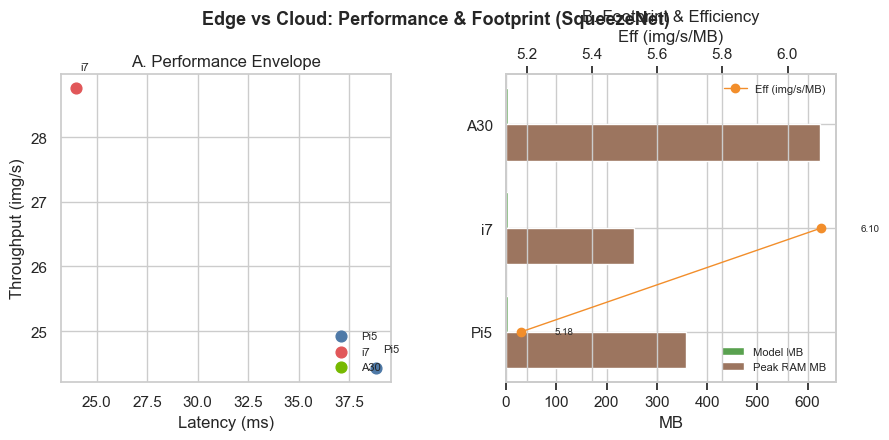

,Platform,Tag,Median_ms,Throughput_img_s,Model_MB,Peak_RAM_MB
1,Raspberry Pi,Pi5,38.810670,24.426217,4.713043,358.859375
0,PC,i7,23.976251,28.759553,4.713043,254.570312
2,NVIDIA GPU,A30,1.762779,NaN,4.713043,625.125000


In [42]:
# Composite Research Figure: Performance & Footprint (2 panels in one row)
import matplotlib.pyplot as plt, numpy as np, pandas as pd, seaborn as sns
sns.set_theme(style='whitegrid')

if 'platform_results' not in globals() or not platform_results:
    print('platform_results is empty; run the loading cell first.')
else:
    recs=[]
    for plat,data in platform_results.items():
        stats=data['core_performance']['statistics']
        inf_times=data['core_performance'].get('inference_times', [])
        batch_info=data.get('batch_processing', {})
        batch1=None
        for k,v in batch_info.items():
            if str(k)=='1': batch1=v; break
        throughput = batch1.get('throughput') if batch1 else np.nan
        model_mb = data['model_info'].get('size_mb', np.nan)
        peak_ram = stats.get('peak_memory_usage', np.nan)
        median = np.median(inf_times) if inf_times else np.nan
        q1 = np.percentile(inf_times,25) if inf_times else np.nan
        q3 = np.percentile(inf_times,75) if inf_times else np.nan
        iqr = q3 - q1 if inf_times else np.nan
        recs.append({
            'Platform':plat,
            'Tag':short_tag(plat) if 'short_tag' in globals() else plat[:10],
            'Median_ms':median,
            'Q1_ms':q1,
            'Q3_ms':q3,
            'IQR_ms':iqr,
            'Throughput_img_s':throughput,
            'Model_MB':model_mb,
            'Peak_RAM_MB':peak_ram
        })
    dfc=pd.DataFrame(recs)
    if dfc.empty:
        print('No records to visualize.')
    else:
        # Order devices Pi5, i7, A30 (removed Colab)
        order=[t for t in ['Pi5','i7','A30'] if t in dfc['Tag'].values]
        if order:
            dfc['Tag']=pd.Categorical(dfc['Tag'], categories=order, ordered=True)
            dfc=dfc.sort_values('Tag')
        palette=dict(zip(order if order else dfc['Tag'].unique(), ['#4E79A7','#E15759','#76B900']))

        fig, axes = plt.subplots(1,2, figsize=(10,4), gridspec_kw={'wspace':0.35})

        # Panel 1: Performance Envelope (Latency vs Throughput)
        ax1=axes[0]
        for _,r in dfc.iterrows():
            ax1.scatter(r['Median_ms'], r['Throughput_img_s'], s=60, color=palette.get(r['Tag'],'#888'), label=r['Tag'])
            ax1.text(r['Median_ms']*1.01, r['Throughput_img_s']*1.01, r['Tag'], fontsize=8)
        ax1.set_xlabel('Latency (ms)')
        ax1.set_ylabel('Throughput (img/s)')
        ax1.set_title('A. Performance Envelope')
        # De-duplicate legend
        handles, labels = ax1.get_legend_handles_labels()
        uniq = dict(zip(labels, handles))
        ax1.legend(uniq.values(), uniq.keys(), frameon=False, fontsize=8, loc='lower right')

        # Panel 2: Footprint + Efficiency (bars + line) => 2-in-1
        ax2=axes[1]
        y_pos=np.arange(len(dfc))
        bar_h=0.35
        ax2.barh(y_pos+bar_h/2, dfc['Model_MB'], height=bar_h, color='#59A14F', label='Model MB')
        ax2.barh(y_pos-bar_h/2, dfc['Peak_RAM_MB'], height=bar_h, color='#9C755F', label='Peak RAM MB')
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(dfc['Tag'])
        ax2.set_xlabel('MB')
        ax2.set_title('B. Footprint & Efficiency')
        # Efficiency line (Throughput per MB model) on twin axis
        eff = dfc['Throughput_img_s'] / dfc['Model_MB']
        ax2b = ax2.twiny()
        ax2b.plot(eff, y_pos, marker='o', color='#F28E2B', linewidth=1, label='Eff (img/s/MB)')
        ax2b.set_xlabel('Eff (img/s/MB)')
        # Build combined legend manually
        l1=ax2.legend(frameon=False, fontsize=8, loc='lower right')
        l2=ax2b.legend(frameon=False, fontsize=8, loc='upper right')
        for i,(e,v) in enumerate(zip(eff, y_pos)):
            ax2b.text(e*1.02, v, f'{e:.2f}', fontsize=7, va='center')

        fig.suptitle('Edge vs Cloud: Performance & Footprint (SqueezeNet)', fontsize=13, fontweight='bold', y=1.04)
        plt.tight_layout()
        plt.show()
        display(dfc[['Platform','Tag','Median_ms','Throughput_img_s','Model_MB','Peak_RAM_MB']])

/var/folders/h5/hc2xh1kd70zcs1snh4247v2w0000gn/T/ipykernel_50607/3389683857.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig1.tight_layout()


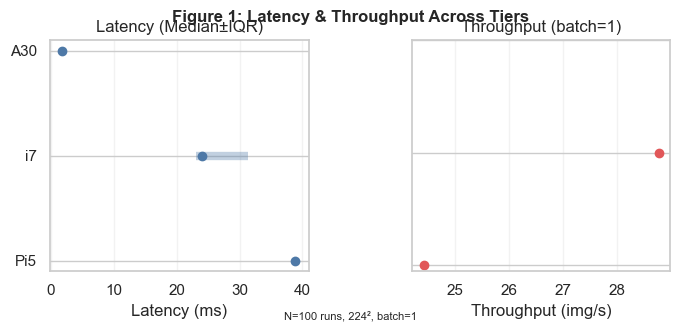

/var/folders/h5/hc2xh1kd70zcs1snh4247v2w0000gn/T/ipykernel_50607/3389683857.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout()


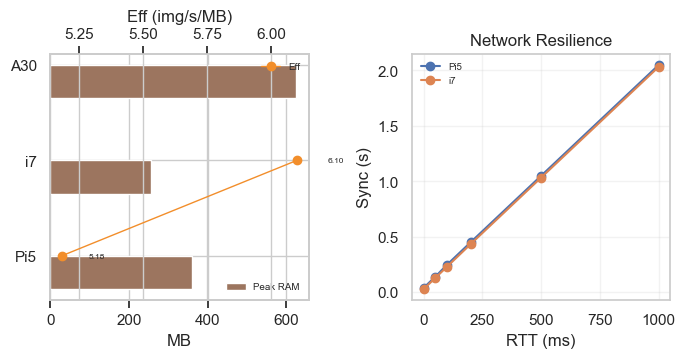

,Platform,Tag,Median_ms,Throughput,Model_MB,Peak_RAM_MB
1,Raspberry Pi,Pi5,38.810670,24.426217,4.713043,358.859375
0,PC,i7,23.976251,28.759553,4.713043,254.570312
2,NVIDIA GPU,A30,1.762779,NaN,4.713043,625.125000


In [43]:
# Two external presentation figures
# Figure 1: Latency (Median±IQR) + Throughput (batch=1) in one figure
# Figure 2: Footprint (Model & Peak RAM + Efficiency) + Network Resilience
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')

if 'platform_results' not in globals() or not platform_results:
    print('platform_results empty; run loader cell first.')
else:
    # Assemble core metrics
    rows=[]
    for plat,data in platform_results.items():
        stats=data['core_performance']['statistics']
        inf_times=data['core_performance'].get('inference_times', [])
        batch=data.get('batch_processing', {})
        b1=None
        for k,v in batch.items():
            if str(k)=='1': b1=v; break
        thr = b1.get('throughput') if b1 else np.nan
        arr=np.array(inf_times) if inf_times else np.array([])
        med=np.median(arr) if arr.size else np.nan
        q1=np.percentile(arr,25) if arr.size else np.nan
        q3=np.percentile(arr,75) if arr.size else np.nan
        model_mb=data['model_info'].get('size_mb', np.nan)
        peak_ram=stats.get('peak_memory_usage', np.nan)
        net_prof=[]
        for d,v in data.get('latency_analysis', {}).items():
            try:
                dd=int(d); mt=v.get('mean_total')
                if mt is not None: net_prof.append((dd, mt/1000.0))
            except: pass
        tag = short_tag(plat) if 'short_tag' in globals() else plat[:10]
        rows.append({'Platform':plat,'Tag':tag,'Median_ms':med,'Q1_ms':q1,'Q3_ms':q3,'Throughput':thr,'Model_MB':model_mb,'Peak_RAM_MB':peak_ram,'Net_Profile':sorted(net_prof)})
    dfp=pd.DataFrame(rows)
    order=[t for t in ['Pi5','i7','A30'] if t in dfp['Tag'].values]
    if order:
        dfp['Tag']=pd.Categorical(dfp['Tag'], categories=order, ordered=True)
        dfp=dfp.sort_values('Tag')

    # ---------------- Figure 1 ----------------
    fig1, axes = plt.subplots(1,2, figsize=(8,3), gridspec_kw={'wspace':0.4})
    # Latency subplot
    axL=axes[0]
    for i,(idx,r) in enumerate(dfp.iterrows()):
        if not np.isnan(r['Median_ms']):
            axL.hlines(i, r['Q1_ms'], r['Q3_ms'], color='#4E79A7', lw=6, alpha=0.35)
            axL.plot(r['Median_ms'], i, 'o', color='#4E79A7')
    axL.set_yticks(range(len(dfp)))
    axL.set_yticklabels(dfp['Tag'])
    axL.set_xlabel('Latency (ms)')
    axL.set_title('Latency (Median±IQR)')
    axL.grid(axis='x', alpha=0.25)
    # Throughput subplot
    axT=axes[1]
    for i,(idx,r) in enumerate(dfp.iterrows()):
        if not np.isnan(r['Throughput']):
            axT.plot(r['Throughput'], i, 'o', color='#E15759')
    axT.set_yticks(range(len(dfp)))
    axT.set_yticklabels([])  # share visual row labels from first
    axT.set_xlabel('Throughput (img/s)')
    axT.set_title('Throughput (batch=1)')
    axT.grid(axis='x', alpha=0.25)
    # Caption under figure 1
    n_vals = [len(platform_results[p]['core_performance'].get('inference_times', [])) for p in platform_results]
    try:
        unified_n = n_vals[0] if len(set(n_vals))==1 else None
    except: unified_n=None
    caption1 = f"N={unified_n} runs, 224², batch=1" if unified_n else "Batch=1, 224² input"
    fig1.suptitle('Figure 1: Latency & Throughput Across Tiers', fontsize=12, fontweight='bold')
    fig1.text(0.5,-0.05, caption1, ha='center', fontsize=8)
    fig1.tight_layout()
    plt.show()

    # ---------------- Figure 2 ----------------
    fig2, axes2 = plt.subplots(1,2, figsize=(8,3.2), gridspec_kw={'wspace':0.4})
    # Footprint + Efficiency (horizontal bars + efficiency points on twin axis)
    axF=axes2[0]
    y=np.arange(len(dfp))
    h=0.35
    axF.barh(y-h/2, dfp['Peak_RAM_MB'], height=h, color='#9C755F', label='Peak RAM')
    axF.set_yticks(y)
    axF.set_yticklabels(dfp['Tag'])
    axF.set_xlabel('MB')
    eff = dfp['Throughput']/dfp['Model_MB']
    axF2=axF.twiny()
    axF2.plot(eff, y, marker='o', color='#F28E2B', linewidth=1, label='Eff')
    axF2.set_xlabel('Eff (img/s/MB)')
    for e,yy in zip(eff,y):
        if not np.isnan(e): axF2.text(e*1.02, yy, f'{e:.2f}', fontsize=6, va='center')
    axF.legend(frameon=False, fontsize=7, loc='lower right')
    axF2.legend(frameon=False, fontsize=7, loc='upper right')

    # Network Resilience (Sync time vs RTT)
    axN=axes2[1]
    for _,r in dfp.iterrows():
        prof=r['Net_Profile']
        if not prof: continue
        d=[p[0] for p in prof]; s=[p[1] for p in prof]
        axN.plot(d,s, marker='o', linewidth=1.5, label=r['Tag'])
    axN.set_xlabel('RTT (ms)')
    axN.set_ylabel('Sync (s)')
    axN.set_title('Network Resilience')
    axN.grid(axis='both', alpha=0.25)
    axN.legend(frameon=False, fontsize=7, loc='upper left')
    fig2.tight_layout()
    plt.show()

    display(dfp[['Platform','Tag','Median_ms','Throughput','Model_MB','Peak_RAM_MB']])